# 3.1. 진동하는 줄 — 변수분리법

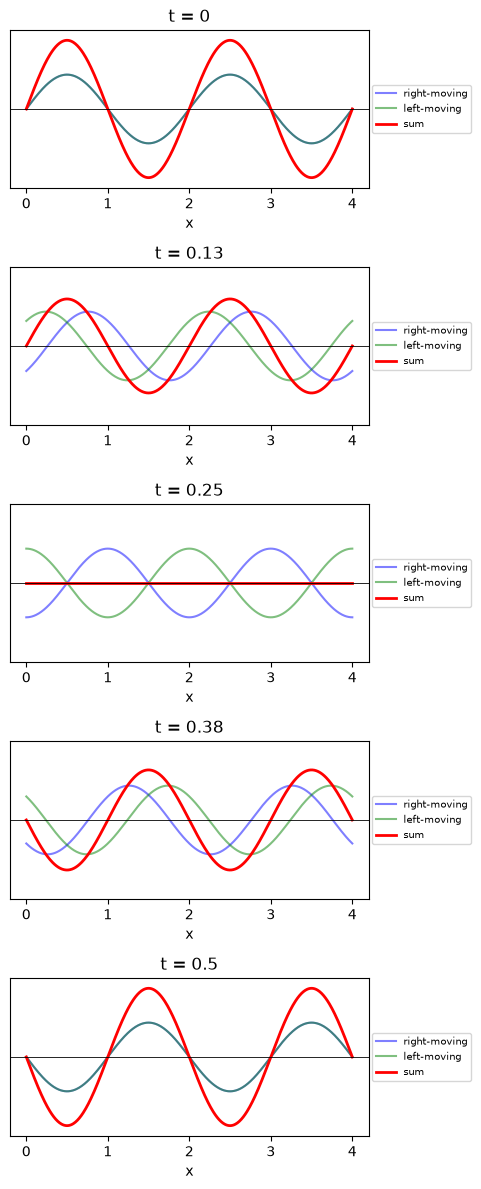

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4, 500)
k, w = np.pi, 2 * np.pi

fig, axes = plt.subplots(5, 1, figsize=(5, 12))

for t, ax in zip([0, 0.13, 0.25, 0.38, 0.5], axes):
    right = np.sin(k * x - w * t)  # 오른쪽으로 진행하는 파동
    left = np.sin(k * x + w * t)  # 왼쪽으로 진행하는 파동
    ax.plot(x, right, color="blue", lw=1.5, alpha=0.5, label="right-moving")
    ax.plot(x, left, color="green", lw=1.5, alpha=0.5, label="left-moving")
    ax.plot(x, right + left, color="red", lw=2, label="sum")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylim(-2.3, 2.3)
    ax.set_yticks([])
    ax.set_xlabel("x")
    ax.set_title(f"t = {t}")
    ax.legend(bbox_to_anchor=(1.3, 0.5), fontsize=7, loc="right")

plt.tight_layout()
plt.show()

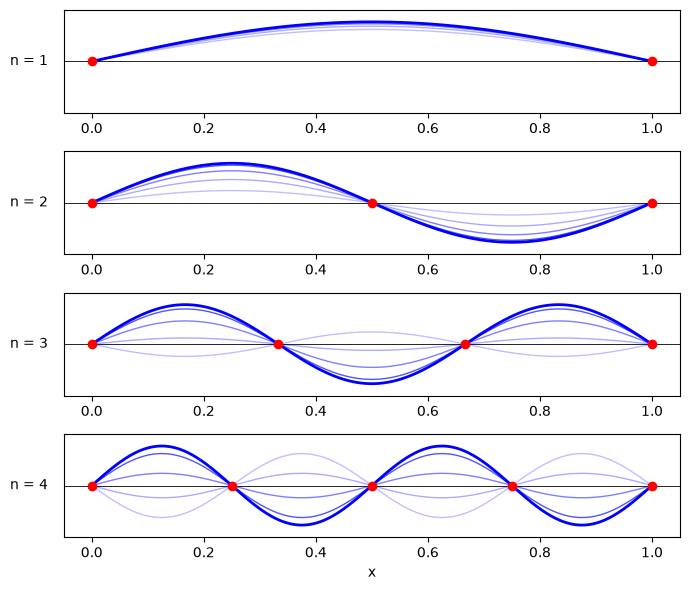

In [2]:
L = 1.0
v = 1.0
x = np.linspace(0, L, 500)

fig, axes = plt.subplots(4, 1, figsize=(7, 6))

for n, ax in zip(range(1, 5), axes):
    X = np.sin(n * np.pi * x / L)
	
    for t, alpha in [(0, 1.0), (0.05, 0.67), (0.1, 0.5), (0.15, 0.33), (0.2, 0.25)]:
        T = np.cos(n * np.pi * v * t / L)
        ax.plot(x, X * T, color="blue", lw=2 if t == 0 else 1, alpha=alpha)
    nodes = np.arange(0, n + 1) * L / n
    ax.plot(nodes, np.zeros_like(nodes), "o", color="red", ms=6, zorder=5)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylim(-1.3, 1.3)
    ax.set_yticks([])
    ax.set_ylabel(f"n = {n}", rotation=0, labelpad=25, va='center')

axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()

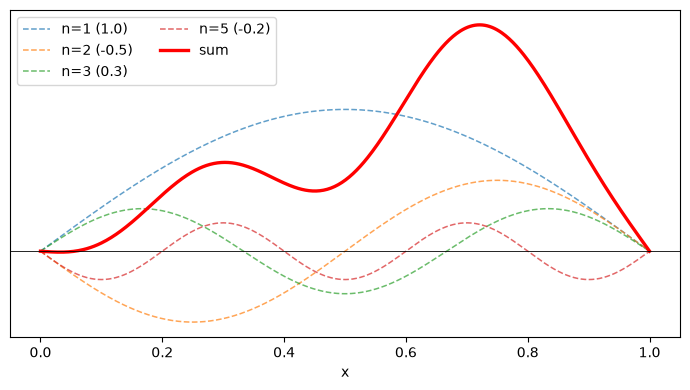

In [3]:
coeff = {1: 1.0, 2: -0.5, 3: 0.3, 5: -0.2}  # 각 모드를 얼마나 섞을 것인가

fig, ax = plt.subplots(figsize=(7, 4))
total = np.zeros_like(x)

for n, c in coeff.items():
    mode = c * np.sin(n * np.pi * x / L)
    total += mode
    ax.plot(x, mode, lw=1.1, ls="--", alpha=0.7, label=f"n={n} ({c})")

ax.plot(x, total, color="red", lw=2.4, label="sum")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("x")
ax.set_yticks([])
ax.legend(ncol=2)

plt.tight_layout()
plt.show()